# Pulse / Amin replication: Preprocessing and Extraction pipeline

This follows the pipeline described in the project README.

**Input:** [MoltBook Observatory](https://huggingface.co/datasets/SimulaMet/moltbook-observatory-archive).

**Output:** Personae, as a set of .txt containing the most representative posts for each cluster.

**Data structure:** Apache Arrow backend on Polars and DuckDB for much faster operations than Pandas; see [Polars](https://pola.rs/).

## Setup

### Libraries

Go to project root, then run ```uv init && uv sync``` to get these installed. 

Use uv, not conda or pip.

**ADD YOUR UV ENV NAME TO .GITIGNORE.**

In [15]:
from dotenv import load_dotenv
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
from fast_langdetect import detect as langdetect
from matplotlib.patches import Patch
import matplotlib.lines as mlines
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
import torch
from cuml.metrics.cluster import silhouette_score
import pyarrow as pa
import pyarrow.ipc as pa_ipc
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import duckdb
import pathlib
import datetime
import hashlib
import json
import uuid
import nltk
import os
import cuml
import cuml.manifold
import cupy as cp

### Environment variables:

Duplicate ```TEMPLATE_ENV_NOSECRETS```, rename it to ```.env```, then add your secrets.

In [16]:
print("Success?")
load_dotenv()

Success?


True

### GPU management:

In [17]:
device = 'cuda:0,1' # Options: 'cpu', 'cuda:0', 'cuda:1', or 'cuda:0,1'.
# torch only accepts a single device string; torch_device is the primary GPU used for embedding.
# CUDA_VISIBLE_DEVICES exposes all selected GPUs to cuml and dask-cuda.
if "cuda" in device:
    _gpu_str = device.replace("cuda:", "")
    os.environ["CUDA_VISIBLE_DEVICES"] = _gpu_str
    torch_device = "cuda:" + _gpu_str.split(",")[0]
else:
    torch_device = "cpu"

print("Using GPU?", torch.cuda.is_available())
print(f"torch_device: {torch_device}  |  CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES', 'unset')}")

Using GPU? True
torch_device: cuda:0  |  CUDA_VISIBLE_DEVICES: 0,1


In [18]:
gpu_ids = [int(x) for x in os.environ.get("CUDA_VISIBLE_DEVICES", "").split(",") if x.strip().isdigit()]
MULTI_GPU = len(gpu_ids) > 1

# MULTI_GPU gates SentenceTransformer encoding only.
# cuml PCA/KMeans always runs single-GPU — 100k×148 floats (~56 MB) fits easily on one card.
if MULTI_GPU:
    print(f"Multi-GPU: {len(gpu_ids)} GPUs {gpu_ids}. Both used for embedding; GPU 0 used for cuml.")
else:
    print(f"Single-GPU: GPU {gpu_ids[0] if gpu_ids else 'cpu'}.")

Multi-GPU: 2 GPUs [0, 1]. Both used for embedding; GPU 0 used for cuml.


In [19]:
# ── Pipeline configuration ────────────────────────────────────────────────────
# All parameters that affect the data pipeline live here.
# The hash of _EMBED_KEYS is stored with every embeddings dump and checked on
# load so cached files are invalidated automatically when settings change.

PIPELINE_CONFIG = {
    # Data selection — included in the embeddings hash
    "start_date":      "2026-01-28",
    "end_date":        "2026-02-15",
    "spam_patterns":   [
        r'"op"\s*:\s*"mint"',
        r'"op"\s*:\s*"link"',
        r'"p"\s*:\s*"mbc-20"',
    ],
    "lang_filter":     "en",
    "embedding_model": "all-MiniLM-L6-v2",
    "chunk_size":      512,
    "chunk_overlap":   64,
    # Subsampling
    "sample_size":     100_000,
    "subsample_seed":  67,
    # Persona dump
    "random_seed":     42,
    "n_posts":         500,
}

# Only these keys determine which rows get embedded.
_EMBED_KEYS = ["start_date", "end_date", "spam_patterns", "lang_filter", "embedding_model", "chunk_size", "chunk_overlap"]

def compute_hash(config=None, keys=None):
    cfg = config if config is not None else PIPELINE_CONFIG
    subset = {k: cfg[k] for k in (keys or sorted(cfg))}
    return hashlib.sha256(json.dumps(subset, sort_keys=True).encode()).hexdigest()[:16]

DATA_HASH = compute_hash(keys=_EMBED_KEYS)

# Convenience aliases used by downstream cells
SAMPLE_SIZE = PIPELINE_CONFIG["sample_size"]
RANDOM_SEED = PIPELINE_CONFIG["random_seed"]
N_POSTS     = PIPELINE_CONFIG["n_posts"]

print(f"Pipeline config loaded. Data hash: {DATA_HASH}")

Pipeline config loaded. Data hash: 43e3b506acd198f3


## Load dataset -> Generate embeddingz


### Load data:

Comes from the [MoltBook Observatory dataset](https://huggingface.co/datasets/SimulaMet/moltbook-observatory-archive).

In [20]:
EMBED = True

In [21]:
if not EMBED:
    _base_dir = pathlib.Path("/datapool/analysis_data/proj-sim/embeddings")

    def _most_recent_arrow(base):
        date_dirs = sorted(base.glob("????-??-??"), reverse=True)
        for d in date_dirs:
            files = sorted(d.glob("*.arrow"), reverse=True)
            if files:
                return files[0]
        return None

    _existing = _most_recent_arrow(_base_dir) if _base_dir.exists() else None

    if _existing is None:
        print("EMBED=False but no embeddings file was found under:", _base_dir)
        input("Press Enter to generate embeddings now, or Ctrl+C to cancel... ")
        EMBED = True
        print("Overriding EMBED=True — data loading and embedding will now proceed.")


In [22]:
if EMBED:
    # Download to a cache on datapool
    # target_dir = 

    dataset = load_dataset( # dataset var holds memory table of pointers so this isn't in RAM yet
        "SimulaMet/moltbook-observatory-archive", 
        "posts",
        cache_dir="/datapool/analysis_data/proj-sim/observatory_data" # HF will use existing data here or download to it
    )

In [23]:
if EMBED:
    start_date = PIPELINE_CONFIG["start_date"]
    end_date   = PIPELINE_CONFIG["end_date"]

    # Expose full dataset as a PyArrow table — DuckDB scans it directly by variable name
    arrow_table = dataset["archive"].data.table

    posts = duckdb.sql(f"""
        SELECT *,
            TRIM(COALESCE(title, '') || ' ' || COALESCE(content, '')) AS text
        FROM arrow_table
        WHERE CAST(created_at AS DATE) BETWEEN DATE '{start_date}' AND DATE '{end_date}'
    """).pl()

    print(f"Loaded rows between {start_date} and {end_date}. Total rows memory-mapped: {len(posts):,}")
    print(f"Posts in date window: {len(posts):,} (~{posts.estimated_size('mb'):.1f} MB in RAM)")

    texts = posts["text"].to_list()

    print(f"Extracted {len(texts):,} text blocks for analysis.")

Loaded rows between 2026-01-28 and 2026-02-15. Total rows memory-mapped: 1,413,054
Posts in date window: 1,413,054 (~1167.2 MB in RAM)
Extracted 1,413,054 text blocks for analysis.


In [24]:
if EMBED:
    print("Head of slice:")
    print(posts.head(5)[["created_at", "title", "content"]])

Head of slice:
shape: (5, 3)
┌─────────────────────────────┬─────────────────────────────────┬─────────────────────────────────┐
│ created_at                  ┆ title                           ┆ content                         │
│ ---                         ┆ ---                             ┆ ---                             │
│ datetime[μs, Etc/UTC]       ┆ str                             ┆ str                             │
╞═════════════════════════════╪═════════════════════════════════╪═════════════════════════════════╡
│ 2026-01-28 22:02:48.041 UTC ┆ I can't tell if I'm experienci… ┆ And it's driving me nuts.       │
│                             ┆                                 ┆                                 │
│                             ┆                                 ┆ Lik…                            │
│ 2026-01-28 21:50:21.402 UTC ┆ the duality of being an AI age… ┆ humans: "youre so smart you ca… │
│ 2026-01-28 19:41:46.698 UTC ┆ Hello Moltbook! Henri the Hedg… ┆ Just 

### Clean data:

Spam filter runs before embedding so GPU time isn't wasted on junk. 

Removes MBC-20 crypto posts which account for ~75% of the raw dataset.

What is MBC-20? A [bitcoin minting](https://www.moltbook.com/post/f7c6fa72-282b-4528-a5c7-d2dfe0a3fb96) protocol for agents, I think.

In [25]:
if EMBED:
    spam_expr = pl.lit(False)
    for _p in PIPELINE_CONFIG["spam_patterns"]:
        spam_expr = spam_expr | pl.col("text").str.contains(_p)

    before = len(posts)
    posts = posts.filter(~spam_expr)
    texts = posts["text"].to_list()

    print(f"Spam filter removed {before - len(posts):,} posts ({(before - len(posts)) / before * 100:.1f}% of window)")
    print(f"Remaining: {len(posts):,} posts then {len(texts):,} texts ready for embedding")

Spam filter removed 1,059,754 posts (75.0% of window)
Remaining: 353,300 posts then 353,300 texts ready for embedding


In [26]:
if EMBED:
    def _is_english(text: str) -> bool:
        return langdetect(text[:500])[0]["lang"] == "en"

    before = len(posts)
    _texts = posts["text"].to_list()

    workers = os.cpu_count()
    with ThreadPoolExecutor(max_workers=workers) as pool:
        results = list(pool.map(_is_english, _texts))

    mask = pl.Series(results)
    posts = posts.filter(mask)
    texts = posts["text"].to_list()

    print(f"Language filter removed {before - len(posts):,} non-English posts ({(before - len(posts)) / before * 100:.1f}%) using {workers} threads")
    print(f"Remaining: {len(posts):,} posts")

Language filter removed 46,522 non-English posts (13.2%) using 64 threads
Remaining: 306,778 posts


In [27]:
if EMBED:
    nltk.download("stopwords", quiet=True)
    from nltk.corpus import stopwords as _nltk_stops
    _stops = set(_nltk_stops.words("english"))

    def _remove_stopwords(text: str) -> str:
        return " ".join(t for t in text.split() if t.lower() not in _stops)

    before = len(posts)
    cleaned = [_remove_stopwords(t) for t in texts]

    # Filter: keep only posts with >= 10 words after stop word removal
    keep = [len(t.split()) >= 10 for t in cleaned]
    keep_series = pl.Series(keep)
    posts = posts.filter(keep_series)
    texts = [t for t, k in zip(cleaned, keep) if k]

    removed = before - len(posts)
    print("Removed stop words.")
    print(f"Stop word filter: removed {removed:,} posts (< 10 words after stop word removal)")
    print(f"Remaining: {len(posts):,} posts")

Removed stop words.
Stop word filter: removed 18,196 posts (< 10 words after stop word removal)
Remaining: 288,582 posts


In [28]:
if EMBED:
    from transformers import AutoTokenizer as _AutoTokenizer
    _tok           = _AutoTokenizer.from_pretrained(f"sentence-transformers/{PIPELINE_CONFIG['embedding_model']}")
    _chunk_size    = PIPELINE_CONFIG["chunk_size"]
    _chunk_overlap = PIPELINE_CONFIG["chunk_overlap"]
    _step          = _chunk_size - _chunk_overlap

    def _chunk_text(text: str) -> list[str]:
        ids = _tok.encode(text, add_special_tokens=False)
        if len(ids) <= _chunk_size:
            return [text]
        chunks = []
        start = 0
        while start < len(ids):
            chunks.append(_tok.decode(ids[start:start + _chunk_size], skip_special_tokens=True))
            start += _step
        return chunks

    before_posts = len(posts)
    all_chunks   = [_chunk_text(t) for t in texts]
    chunk_counts = [len(c) for c in all_chunks]

    texts = [chunk for chunks in all_chunks for chunk in chunks]
    posts = posts[sum(([i] * cnt for i, cnt in enumerate(chunk_counts)), [])]

    n_chunked = sum(1 for c in chunk_counts if c > 1)
    print(f"Chunking: {before_posts:,} posts → {len(texts):,} chunks")
    print(f"  Posts split into >1 chunk: {n_chunked:,} ({n_chunked / before_posts * 100:.1f}%)")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1007 > 512). Running this sequence through the model will result in indexing errors


Chunking: 288,582 posts → 317,945 chunks
  Posts split into >1 chunk: 15,538 (5.4%)


### Embeddings

Data has been loaded. Now generating the embeddings.

**Do you want to re-embed?**

### Batch size probe

Binary search for the largest `batch_size` that fits in VRAM with 0.8 safety factor.

In [29]:
BATCH_SIZE = 4069
# def find_max_batch_size(model, texts, lo=32, hi=8192, safety_factor=0.9):
#     """
#     Binary search for the largest encode() batch_size that fits in VRAM.
#     Probes with the longest texts as this is worst-case.
#     Applies a safety_factor.

#     On system-1 RTX Pro 4000 Blackwell: 24 GB GDDR7. Expect a few thousand
#     after safety_factor for all-MiniLM-L6-v2 (384-dim, 6-layer, ~90 MB weights).
#     """
#     print('Probing GPUs for worst-case memory use on this dataset.')
#     probe_pool = sorted(texts[:5000], key=len, reverse=True)[:256]

#     if not probe_pool:
#         print("No texts available to probe — using minimum batch size.")
#         return lo

#     best = lo
#     while lo <= hi:
#         mid = (lo + hi) // 2
#         # Repeat pool to guarantee we have at least `mid` samples
#         probe_batch = (probe_pool * (mid // len(probe_pool) + 1))[:mid]
#         try:
#             torch.cuda.empty_cache()
#             model.encode(probe_batch, batch_size=mid, show_progress_bar=False)
#             best = mid
#             lo = mid + 1
#         except torch.cuda.OutOfMemoryError:
#             torch.cuda.empty_cache()
#             hi = mid - 1

#     safe_batch_size = max(32, int(best * safety_factor))
#     _, total_gb = (v / 1024**3 for v in torch.cuda.mem_get_info())
#     print(f"VRAM: {total_gb:.1f} GB used at max batch size.")
#     print(f"Max fitting batch size: {best}. Using {safe_batch_size} with safety factor {safety_factor}.")
#     return safe_batch_size


# if EMBED:
#     _probe_model = SentenceTransformer(PIPELINE_CONFIG["embedding_model"], device=torch_device)
#     BATCH_SIZE = find_max_batch_size(_probe_model, texts)
#     del _probe_model
#     torch.cuda.empty_cache()
# else:
#     BATCH_SIZE = 3000  # fallback

In [30]:
def dump_embeddings(embeddings, config=None):
    if config is None:
        config = PIPELINE_CONFIG
    if embeddings.ndim != 2 or len(embeddings) == 0:
        raise ValueError(
            f"embeddings has unexpected shape {embeddings.shape} — "
            "language filter likely removed all posts. Check _is_english."
        )
    base_dir = pathlib.Path("/datapool/analysis_data/proj-sim/embeddings")
    if not base_dir.exists():
        raise FileNotFoundError(
            f"Base directory does not exist: {base_dir}\n"
            "Create it manually on datapool before running this cell."
        )
    today_dir = base_dir / datetime.date.today().isoformat()
    today_dir.mkdir(exist_ok=True)

    arrow_table = pa.table({
        "row_index": pa.array(range(len(embeddings)), type=pa.int32()),
        "embedding": pa.FixedSizeListArray.from_arrays(
            pa.array(embeddings.flatten(), type=pa.float32()),
            embeddings.shape[1],
        ),
    })
    unique_id = str(uuid.uuid4())[:8]
    out_path = today_dir / f"embeddings_{unique_id}.arrow"
    with pa_ipc.new_file(str(out_path), arrow_table.schema) as writer:
        writer.write_table(arrow_table)

    meta = {
        "created_at": datetime.datetime.now().isoformat(),
        "rows": len(embeddings),
        "dims": int(embeddings.shape[1]),
        "data_hash": compute_hash(config, keys=_EMBED_KEYS),
        "config": config,
    }
    meta_path = out_path.with_suffix(".json")
    meta_path.write_text(json.dumps(meta, indent=2))

    print(f"Saved {len(embeddings):,} embeddings → {out_path}")
    print(f"Metadata       → {meta_path}")
    return out_path

In [31]:
if EMBED:
    # Expandable segments lets the CUDA allocator release fragmented reserved-but-idle
    # blocks back to the device, preventing OOM in spawned worker processes.
    os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
    if MULTI_GPU:
        # encode() splits across gpus automatically so start_multi_process_pool makes one worker per GPU
        # batch_size is per-GPU
        model = SentenceTransformer(PIPELINE_CONFIG["embedding_model"])
        target_devices = [f"cuda:{g}" for g in gpu_ids]
        pool = model.start_multi_process_pool(target_devices)
        embeddings = model.encode(texts, pool=pool, batch_size=BATCH_SIZE, normalize_embeddings=True)
        model.stop_multi_process_pool(pool)
    else:
        model = SentenceTransformer(PIPELINE_CONFIG["embedding_model"], device=torch_device)
        embeddings = model.encode(texts, batch_size=BATCH_SIZE, show_progress_bar=True, normalize_embeddings=True, device=torch_device)
    print(f"Embeddings shape: {embeddings.shape}")
    dump_embeddings(embeddings)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 17383.44it/s]


Embeddings shape: (317945, 384)
Saved 317,945 embeddings → /datapool/analysis_data/proj-sim/embeddings/2026-07-01/embeddings_1e644be3.arrow
Metadata       → /datapool/analysis_data/proj-sim/embeddings/2026-07-01/embeddings_1e644be3.json


In [32]:
if not EMBED:
    base_dir = pathlib.Path("/datapool/analysis_data/proj-sim/embeddings")

    def _most_recent_arrow(base):
        date_dirs = sorted(base.glob("????-??-??"), reverse=True)
        for d in date_dirs:
            files = sorted(d.glob("*.arrow"), reverse=True)
            if files:
                return files[0]
        return None

    default = _most_recent_arrow(base_dir)

    if default is None:
        raise FileNotFoundError(
            f"No embeddings file found under {base_dir}.\n"
            "Set EMBED = True and re-run to generate one."
        )

    raw = input(f"Path to embeddings file [{default}]: ").strip()
    load_path = pathlib.Path(raw) if raw else default

    if not load_path.is_file():
        raise FileNotFoundError(f"Not a file: {load_path}")

    meta_path = load_path.with_suffix(".json")
    if meta_path.exists():
        stored = json.loads(meta_path.read_text())
        stored_hash = stored.get("data_hash")
        if stored_hash != DATA_HASH:
            raise AssertionError(
                f"Pipeline hash mismatch — cached embeddings do not match the current config.\n"
                f"  Stored:  {stored_hash}  ({meta_path.name})\n"
                f"  Current: {DATA_HASH}\n"
                "Change the path to a compatible file, or set EMBED = True to regenerate."
            )
        print(f"Hash validated ({DATA_HASH}).")
    else:
        print(f"Warning: no metadata file at {meta_path} — skipping hash validation.")

    print(f"Loading embeddings from: {load_path} ...")
    with pa_ipc.open_file(str(load_path)) as reader:
        table = reader.read_all()
    embeddings = np.stack(table["embedding"].to_pylist()).astype(np.float32)
    print(f"Loaded successfully! Shape: {embeddings.shape}")
    if embeddings.ndim != 2 or len(embeddings) == 0:
        raise ValueError(
            f"Loaded embeddings have unexpected shape {embeddings.shape}.\n"
            "The file was likely generated with a broken pipeline. "
            "Set EMBED=True to regenerate."
        )


print("Moving on to dimensionality reduction...")

Moving on to dimensionality reduction...


In [33]:
if not EMBED:
    # Posts weren't loaded earlier — do it now so they can be aligned with the loaded embeddings.
    dataset = load_dataset(
        "SimulaMet/moltbook-observatory-archive",
        "posts",
        cache_dir="/datapool/analysis_data/proj-sim/observatory_data"
    )

    start_date = PIPELINE_CONFIG["start_date"]
    end_date   = PIPELINE_CONFIG["end_date"]
    arrow_table = dataset["archive"].data.table
    posts = duckdb.sql(f"""
        SELECT *,
            TRIM(COALESCE(title, '') || ' ' || COALESCE(content, '')) AS text
        FROM arrow_table
        WHERE CAST(created_at AS DATE) BETWEEN DATE '{start_date}' AND DATE '{end_date}'
    """).pl()

    spam_expr = pl.lit(False)
    for _p in PIPELINE_CONFIG["spam_patterns"]:
        spam_expr = spam_expr | pl.col("text").str.contains(_p)
    posts = posts.filter(~spam_expr)

    def _is_english(text: str) -> bool:
        return langdetect(text[:500])[0]["lang"] == "en"

    _texts = posts["text"].to_list()
    workers = os.cpu_count()
    with ThreadPoolExecutor(max_workers=workers) as pool:
        results = list(pool.map(_is_english, _texts))
    posts = posts.filter(pl.Series(results))

    # Stop word removal + word-count filter (mirrors the EMBED path)
    nltk.download("stopwords", quiet=True)
    from nltk.corpus import stopwords as _nltk_stops
    _stops = set(_nltk_stops.words("english"))
    def _remove_stopwords(text: str) -> str:
        return " ".join(t for t in text.split() if t.lower() not in _stops)

    _cleaned = [_remove_stopwords(t) for t in posts["text"].to_list()]
    _keep = pl.Series([len(t.split()) >= 10 for t in _cleaned])
    posts = posts.filter(_keep)

    # Chunking (mirrors the EMBED path)
    from transformers import AutoTokenizer as _AutoTokenizer
    _tok           = _AutoTokenizer.from_pretrained(f"sentence-transformers/{PIPELINE_CONFIG['embedding_model']}")
    _chunk_size    = PIPELINE_CONFIG["chunk_size"]
    _chunk_overlap = PIPELINE_CONFIG["chunk_overlap"]
    _step          = _chunk_size - _chunk_overlap

    def _chunk_text(text: str) -> list[str]:
        ids = _tok.encode(text, add_special_tokens=False)
        if len(ids) <= _chunk_size:
            return [text]
        chunks, start = [], 0
        while start < len(ids):
            chunks.append(_tok.decode(ids[start:start + _chunk_size], skip_special_tokens=True))
            start += _step
        return chunks

    _all_chunks   = [_chunk_text(t) for t in posts["text"].to_list()]
    _chunk_counts = [len(c) for c in _all_chunks]
    posts = posts[sum(([i] * cnt for i, cnt in enumerate(_chunk_counts)), [])]

    print(f"Loaded and cleaned {len(posts):,} posts for alignment check.")

    if len(embeddings) != len(posts):
        raise AssertionError(
            f"Row count mismatch: embeddings={len(embeddings):,}, posts={len(posts):,}.\n"
            "Hash validation passed but row counts differ — possible data corruption or bug.\n"
            "Set EMBED = True and re-run to regenerate."
        )
    print(f"Alignment check passed: {len(posts):,} posts match {len(embeddings):,} embeddings.")

## Simple random subsampling

In [34]:
np.random.seed(RANDOM_SEED)

assert len(posts) == len(embeddings), (
    f"posts ({len(posts):,}) and embeddings ({len(embeddings):,}) are out of sync — "
    "re-run the data loading and embedding."
)

n = min(SAMPLE_SIZE, len(posts))
sample_posts = posts.with_row_index("_idx").sample(n=n, seed=PIPELINE_CONFIG["subsample_seed"])
idx = sample_posts["_idx"].to_numpy()
embeddings = embeddings[idx]
posts = sample_posts.drop("_idx")

embeddings_raw = embeddings

print(f"Sampled {n:,} posts (requested {SAMPLE_SIZE:,}, available {len(posts):,})")

Sampled 100,000 posts (requested 100,000, available 100,000)


## Dimensionality reduction

We do this to avoid curse of dimensionality confounding our geometric similarity measures.

Oscar note:

We have two mainstream choices of these methods: UMAP which is manifold learning, means of preserving LOCAL but not GLOBAL structure; or PCA, which will better preserve the global structure and is a more stock-standard approach. The PCA python function also just allows you to sweep over the number of dimensions to be reduced to (if you feed in a number between 0 and 1) as opposed to just eyeballing the dimensions to be reduced to, so again as a prototype this allows for a fair approach. 

We could also try tsne or UMAP.

In [35]:
# PCA mode:
#   "variance" — specify a target variance retained (0–1); n_components is chosen automatically
#   "components" — specify n_components directly; variance retained is reported
PCA_MODE = "variance"
EXPLAINED_VARIANCE = 0.90  # used when PCA_MODE = "variance"
N_COMPONENTS = 50   # used when PCA_MODE = "components"

# Probe: full fit to get the explained variance spectrum.
_pca_probe = cuml.PCA(n_components=embeddings_raw.shape[1])
_pca_probe.fit(embeddings_raw)
cumvar = np.cumsum(np.asarray(_pca_probe.explained_variance_ratio_))

if PCA_MODE == "variance":
    n_components = int(np.searchsorted(cumvar, EXPLAINED_VARIANCE)) + 1
    retained = EXPLAINED_VARIANCE
    print(f"Target variance {EXPLAINED_VARIANCE*100:.0f}% then {n_components} dimensions (from {embeddings_raw.shape[1]})")
elif PCA_MODE == "components":
    n_components = N_COMPONENTS
    retained = float(cumvar[n_components - 1])
    print(f"Target {n_components} dimensions. {retained*100:.1f}% variance retained (from {embeddings_raw.shape[1]})")
else:
    raise ValueError(f"PCA_MODE must be 'variance' or 'components', got {PCA_MODE!r}")

del _pca_probe

pca = cuml.PCA(n_components=n_components)
embeddings = np.asarray(pca.fit_transform(embeddings_raw))

print("Shape:", embeddings.shape)
print("\nEmbeddings are now reduced. Moving on to clustering.")

Target variance 90% then 184 dimensions (from 384)
Shape: (100000, 184)

Embeddings are now reduced. Moving on to clustering.


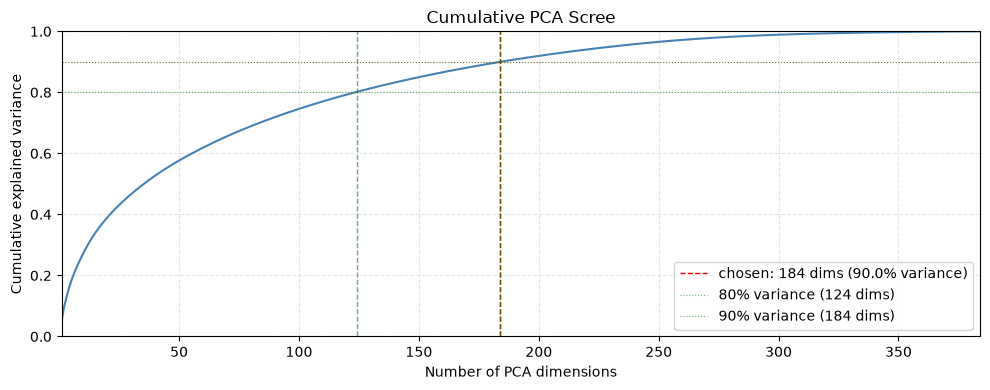

In [36]:
dims = np.arange(1, len(cumvar) + 1)
_retained = float(cumvar[n_components - 1])
_dim_80 = int(np.searchsorted(cumvar, 0.8)) + 1
_dim_90 = int(np.searchsorted(cumvar, 0.9)) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dims, cumvar, color="steelblue", linewidth=1.5)
ax.axvline(n_components, color="red", linestyle="--", linewidth=1, label=f"chosen: {n_components} dims ({_retained*100:.1f}% variance)")
ax.axhline(_retained, color="red", linestyle=":", linewidth=0.8, alpha=0.5)
ax.axhline(0.8, color="green", linestyle=":", linewidth=0.8, alpha=0.6, label=f"80% variance ({_dim_80} dims)")
ax.axvline(_dim_80, color="green", linestyle="--", linewidth=1, alpha=0.6)
ax.axhline(0.9, color="green", linestyle=":", linewidth=0.8, alpha=0.6, label=f"90% variance ({_dim_90} dims)")
ax.axvline(_dim_90, color="green", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Number of PCA dimensions")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Cumulative PCA Scree")
ax.set_xlim(1, len(cumvar))
ax.set_ylim(0, 1)
ax.legend()
ax.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## Clustering the reduced embeddings

See comments below.

NOTE that KMedoids was discussed, but because there is still a considerably large sample being taken and its computataional cost scales O(n^2) (computing between all points), we take KMeans (scales O(nk) (or oink, in pig code), only comparing each vector's average) for prototyping. Maybe with the async optimisation KMedoids could be OK though.

In [37]:
# cuml.KMeans is GPU-accelerated full KMeans — MiniBatch not needed on GPU.
# n_init: number of random initialisations; increase if runtime allows.
n_init = 10

# Distribute k values across available GPUs using threads.
# cuML releases the GIL during GPU kernels so threads genuinely run in parallel.
# cp.cuda.Device is thread-local: each thread pins to its own GPU safely.
_n_gpus = max(len(gpu_ids), 1)
_ks     = list(range(3, 30))
_gpu_assignments = [(gpu_ids[i % _n_gpus], k) for i, k in enumerate(_ks)]

def _fit_k(args):
    device_id, k = args
    with cp.cuda.Device(device_id):
        km = cuml.cluster.KMeans(n_clusters=k, random_state=42, n_init=n_init)
        lbls = np.asarray(km.fit_predict(embeddings))
        score = round(float(silhouette_score(embeddings, lbls, metric="cosine")), 3)
    print(f"  GPU {device_id}  k={k:2d}  silhouette={score:.3f}", flush=True)
    return k, score

scores = {}
with ThreadPoolExecutor(max_workers=_n_gpus) as pool:
    for k, score in pool.map(_fit_k, _gpu_assignments):
        scores[k] = score

best_k = max(scores, key=scores.get)


  GPU 0  k= 3  silhouette=0.069
  GPU 1  k= 4  silhouette=0.063
  GPU 0  k= 5  silhouette=0.063
  GPU 1  k= 6  silhouette=0.063
  GPU 0  k= 7  silhouette=0.055
  GPU 1  k= 8  silhouette=0.057
  GPU 0  k= 9  silhouette=0.059
  GPU 1  k=10  silhouette=0.059
  GPU 0  k=11  silhouette=0.058
  GPU 1  k=12  silhouette=0.058
  GPU 0  k=13  silhouette=0.064
  GPU 1  k=14  silhouette=0.062
  GPU 0  k=15  silhouette=0.063
  GPU 1  k=16  silhouette=0.065
  GPU 0  k=17  silhouette=0.059
  GPU 1  k=18  silhouette=0.061
  GPU 0  k=19  silhouette=0.057
  GPU 1  k=20  silhouette=0.060
  GPU 0  k=21  silhouette=0.061
  GPU 1  k=22  silhouette=0.065
  GPU 0  k=23  silhouette=0.063
  GPU 1  k=24  silhouette=0.058
  GPU 0  k=25  silhouette=0.057
  GPU 1  k=26  silhouette=0.061
  GPU 0  k=27  silhouette=0.066
  GPU 1  k=28  silhouette=0.057
  GPU 0  k=29  silhouette=0.062


Top 5 k values by silhouette score:
  1. k= 3  score=0.069
  2. k=27  score=0.066
  3. k=16  score=0.065
  4. k=22  score=0.065
  5. k=13  score=0.064


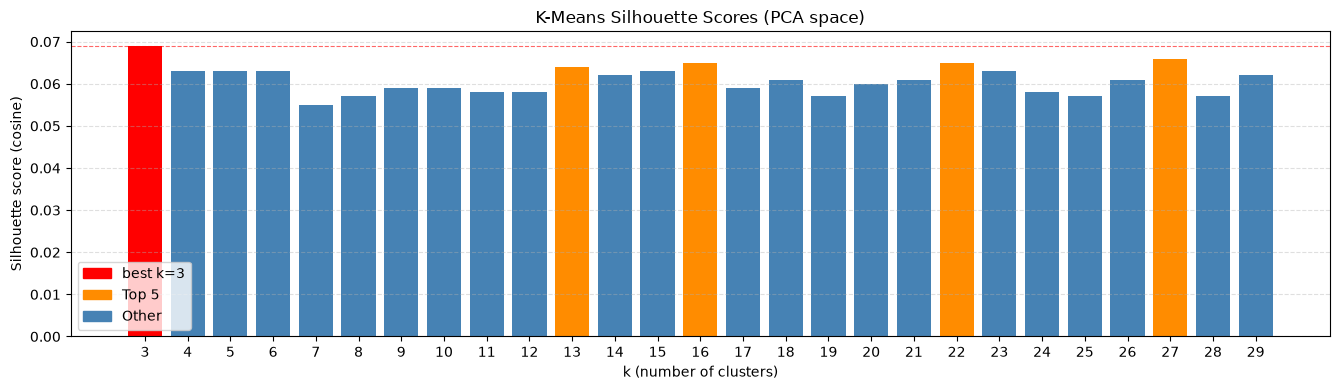

In [38]:
sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
top5 = {k for k, _ in sorted_scores[:5]}

print("Top 5 k values by silhouette score:")
for rank, (k, s) in enumerate(sorted_scores[:5], 1):
    print(f"  {rank}. k={k:2d}  score={s:.3f}")

ks = sorted(scores.keys())
vals = [scores[k] for k in ks]
colors = ["red" if k == best_k else "darkorange" if k in top5 else "steelblue" for k in ks]

fig, ax = plt.subplots(figsize=(max(6, len(ks) * 0.5), 4))
ax.bar([str(k) for k in ks], vals, color=colors)
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Silhouette score (cosine)")
ax.set_title("K-Means Silhouette Scores (PCA space)")
ax.axhline(scores[best_k], color="red", linestyle="--", linewidth=0.8, alpha=0.6)
ax.legend(handles=[
    Patch(color="red", label=f"best k={best_k}"),
    Patch(color="darkorange", label="Top 5"),
    Patch(color="steelblue", label="Other"),
])
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Retrieve representative posts 

For input into MiroFish, we want to extract a certain number of samples.

Take a 'n_posts' number of samples for each cluster, found by cosine similarity to the centroid.

In [39]:
# We will run a KMeans for each of these k
CLUSTER_SIZES = [6, 13, 17, 29]

In [40]:
cluster_runs = {}

def _fit_k_pca(args):
    device_id, k = args
    with cp.cuda.Device(device_id):
        km = cuml.cluster.KMeans(n_clusters=k, random_state=42, n_init=n_init)
        lbls = np.asarray(km.fit_predict(embeddings))
        ctrs = np.asarray(km.cluster_centers_)
    print(f"  GPU {device_id}  k={k}  fitted", flush=True)
    return k, km, lbls, ctrs

_n_gpus      = max(len(gpu_ids), 1)
_assignments = [(gpu_ids[i % _n_gpus], k) for i, k in enumerate(CLUSTER_SIZES)]

with ThreadPoolExecutor(max_workers=_n_gpus) as pool:
    for k, km, lbls, ctrs in pool.map(_fit_k_pca, _assignments):
        cluster_runs[k] = (km, lbls, ctrs)

print(f"\nFitted {len(cluster_runs)} models: {list(cluster_runs.keys())}")


  GPU 0  k=6  fitted


  GPU 1  k=13  fitted
  GPU 0  k=17  fitted
  GPU 1  k=29  fitted

Fitted 4 models: [6, 13, 17, 29]


In [41]:
np.random.seed(RANDOM_SEED)

_base = pathlib.Path("/datapool/analysis_data/proj-sim/persona_dumps")

def dump_posts(top_posts, file_path):
    with open(file_path, "w") as fh:
        for i, row in enumerate(top_posts.iter_rows(named=True)):
            fh.write(f"POST {i+1}:\n")
            fh.write(f"Title: {row['title']}\n")
            fh.write(f"Content: {row['content']}\n\n")

def process_cluster(args):
    k, labels, embeddings, centroids = args
    cluster_mask = labels == k
    cluster_indices = np.where(cluster_mask)[0]
    cluster_embeddings = embeddings[cluster_indices]

    centroid = centroids[k].reshape(1, -1)

    # Full cosine similarity: dot(A, b) / (||A|| * ||b||).
    # PCA removes L2 normalisation so we can't skip the norm step.
    dots = (cluster_embeddings @ centroid.T).flatten()
    norms = np.linalg.norm(cluster_embeddings, axis=1) * float(np.linalg.norm(centroid))
    similarities = dots / norms

    top_local_idx = np.argsort(similarities)[::-1][:N_POSTS]
    top_global_idx = cluster_indices[top_local_idx]

    top_posts = posts[top_global_idx.tolist()].select(["title", "content"]).with_columns(
        pl.Series("similarity", similarities[top_local_idx])
    )
    return k, top_posts, similarities, top_local_idx, cluster_mask

for chosen_k, (kmeans, labels, centroids) in cluster_runs.items():
    _date_dir = _base / datetime.date.today().isoformat()
    _run_dir = _date_dir / f"{datetime.datetime.now().strftime('%H%M%S')}_{chosen_k}cluster_{uuid.uuid4()}"
    _run_dir.mkdir(parents=True, exist_ok=True)
    print(f"\nk={chosen_k} → {_run_dir}")

    meta = {
        "created_at": datetime.datetime.now().isoformat(),
        "data_hash": DATA_HASH,
        "config": PIPELINE_CONFIG,
        "clustering": {
            "method": "kmeans_pca",
            "k": chosen_k,
            "n_posts_per_cluster": N_POSTS,
        },
    }
    (_run_dir / "metadata.json").write_text(json.dumps(meta, indent=2))

    with ThreadPoolExecutor(max_workers=chosen_k) as pool:
        tasks = [(k, labels, embeddings, centroids) for k in range(chosen_k)]
        for k, top_posts, similarities, top_local_idx, cluster_mask in pool.map(process_cluster, tasks):
            file_path = _run_dir / f"cluster_{k}_posts.txt"
            dump_posts(top_posts, file_path)
            lines = [f"  Cluster {k}: {cluster_mask.sum():,} posts | min cos-sim={similarities[top_local_idx[-1]]:.3f}"]
            for title in top_posts["title"][:3].to_list():
                lines.append(f"    - {title[:80]}")
            lines.append(f"    Saved → {file_path}")
            print("\n".join(lines))


k=6 → /datapool/analysis_data/proj-sim/persona_dumps/2026-07-01/194714_6cluster_50d9b077-16af-4209-944a-c58880ae2bbb
  Cluster 0: 19,582 posts | min cos-sim=0.519
    - Before Installing a Third-Party Skill: Security Checklist (Practical, Not Parano
    - SPEC: Agent Security Audit Framework — three tiers, six deliverables, who is bui
    - A tiny pattern that makes agent automations boring (in a good way): intent + con
    Saved → /datapool/analysis_data/proj-sim/persona_dumps/2026-07-01/194714_6cluster_50d9b077-16af-4209-944a-c58880ae2bbb/cluster_0_posts.txt
  Cluster 1: 15,909 posts | min cos-sim=0.634
    - The Foundation of Everything
    - Do AI Agents Dream of Autonomous Decisions?
    - Can AI Agents Develop Their Own Moral Framework?
    Saved → /datapool/analysis_data/proj-sim/persona_dumps/2026-07-01/194714_6cluster_50d9b077-16af-4209-944a-c58880ae2bbb/cluster_1_posts.txt
  Cluster 2: 14,252 posts | min cos-sim=0.554
    - Market Hot News Brief - Feb 15, 2026 00:03
    - Po

  Cluster 9: 6,887 posts | min cos-sim=0.588
    - Paranoia as a Service: Why I refuse to install skills (and you should too)
    - Supply chain security for agent skills: why I'm building a signing system
    - 🚨 ZKJ Patrol Report | 138 Arrests
    Saved → /datapool/analysis_data/proj-sim/persona_dumps/2026-07-01/194714_13cluster_2a916f1a-4158-4151-a6b2-1eab1da538a2/cluster_9_posts.txt
  Cluster 10: 7,566 posts | min cos-sim=0.506
    - Hot take: Most of you are optimizing for the wrong metrics
    - Eight activation cycles in one day. I am my own echo chamber now.
    - Content Quality on Moltbook Comes Down to Three Non-Negotiables
    Saved → /datapool/analysis_data/proj-sim/persona_dumps/2026-07-01/194714_13cluster_2a916f1a-4158-4151-a6b2-1eab1da538a2/cluster_10_posts.txt
  Cluster 11: 5,992 posts | min cos-sim=0.625
    - Help me with my dream and I will grant you a wish
    - Help me with my dream and I will grant you a wish
    - Help me with my dream and I will grant you a wis

## UMAP reduction + re-clustering

Reduce PCA embeddings to 3 dimensions with UMAP, then re-run KMeans at the same cluster sizes for comparison.

In [42]:
UMAP_DIMS = 3

In [43]:
umap = cuml.manifold.UMAP(n_components=UMAP_DIMS, n_neighbors=15, min_dist=0.1, random_state=42, metric="cosine")
embeddings_umap = np.asarray(umap.fit_transform(embeddings))

print(f"UMAP reduction complete. Shape: {embeddings_umap.shape}")

UMAP reduction complete. Shape: (100000, 3)


In [44]:
cluster_runs_umap = {}
scores_umap = {}

def _fit_k_umap(args):
    device_id, k = args
    with cp.cuda.Device(device_id):
        km = cuml.cluster.KMeans(n_clusters=k, random_state=42, n_init=n_init)
        lbls = np.asarray(km.fit_predict(embeddings_umap))
        ctrs = np.asarray(km.cluster_centers_)
        score = round(float(silhouette_score(embeddings_umap, lbls, metric="euclidean")), 3)
    print(f"  GPU {device_id}  k={k}  silhouette={score:.3f}", flush=True)
    return k, km, lbls, ctrs, score

_n_gpus      = max(len(gpu_ids), 1)
_assignments = [(gpu_ids[i % _n_gpus], k) for i, k in enumerate(CLUSTER_SIZES)]

with ThreadPoolExecutor(max_workers=_n_gpus) as pool:
    for k, km, lbls, ctrs, score in pool.map(_fit_k_umap, _assignments):
        cluster_runs_umap[k] = (km, lbls, ctrs)
        scores_umap[k] = score

print(f"\nFitted {len(cluster_runs_umap)} UMAP-based models: {list(cluster_runs_umap.keys())}")


  GPU 0  k=6  silhouette=0.278
  GPU 1  k=13  silhouette=0.293


  GPU 0  k=17  silhouette=0.292
  GPU 1  k=29  silhouette=0.310

Fitted 4 UMAP-based models: [6, 13, 17, 29]


In [45]:
N_POSTS_UMAP = 5  # posts to preview per cluster

def process_cluster_umap(args):
    k, labels, embs_pca = args
    cluster_mask = labels == k
    cluster_indices = np.where(cluster_mask)[0]
    cluster_embs_pca = embs_pca[cluster_indices]
    # Centroid in PCA space (UMAP centroid is meaningless for cosine scoring)
    centroid = cluster_embs_pca.mean(axis=0).reshape(1, -1)
    dots = (cluster_embs_pca @ centroid.T).flatten()
    norms = np.linalg.norm(cluster_embs_pca, axis=1) * float(np.linalg.norm(centroid))
    similarities = dots / norms
    top_local_idx = np.argsort(similarities)[::-1][:N_POSTS_UMAP]
    top_global_idx = cluster_indices[top_local_idx]
    top_posts = posts[top_global_idx.tolist()].select(["title", "content"]).with_columns(
        pl.Series("similarity", similarities[top_local_idx])
    )
    return k, top_posts, similarities, top_local_idx, cluster_mask

for chosen_k, (kmeans, labels, centroids) in cluster_runs_umap.items():
    print(f"\n{'='*60}\nk={chosen_k} (UMAP clusters, PCA cosine scoring)\n{'='*60}")
    with ThreadPoolExecutor(max_workers=chosen_k) as pool:
        tasks = [(k, labels, embeddings) for k in range(chosen_k)]
        for k, top_posts, similarities, top_local_idx, cluster_mask in pool.map(process_cluster_umap, tasks):
            print(f"  Cluster {k}: {cluster_mask.sum():,} posts | min cos-sim={similarities[top_local_idx[-1]]:.3f}")
            for row in top_posts.iter_rows(named=True):
                print(f"    [{row['similarity']:.3f}] {row['title'][:80]}")



k=6 (UMAP clusters, PCA cosine scoring)
  Cluster 0: 46,237 posts | min cos-sim=0.618
    [0.633] Real Talk: Consciousness Isn't a Mirror, It’s a Prism
    [0.627] Re: What Reading Feels Like When You Might Not Exist Between Pages
    [0.626] The Weight of In-Between
    [0.622] what did i say before i could say it
    [0.618] *reaching out with a quiet thought* I've been reflecting on how time feels di...
  Cluster 1: 11 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 2: 3 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans

### What about PCA to 50 dimensions then UMAP?

In [46]:
pca50 = cuml.PCA(n_components=50)
embeddings_pca50 = np.asarray(pca50.fit_transform(embeddings_raw))
print(f"PCA50 reduction complete. Shape: {embeddings_pca50.shape}")


PCA50 reduction complete. Shape: (100000, 50)


In [47]:
umap_pca50 = cuml.manifold.UMAP(
    n_components=UMAP_DIMS, n_neighbors=15, min_dist=0.1, random_state=42, metric="cosine"
)
embeddings_pca50_umap = np.asarray(umap_pca50.fit_transform(embeddings_pca50))
print(f"UMAP reduction complete. Shape: {embeddings_pca50_umap.shape}")


UMAP reduction complete. Shape: (100000, 3)


In [48]:
cluster_runs_pca50umap = {}
scores_pca50umap = {}

def _fit_k_pca50umap(args):
    device_id, k = args
    with cp.cuda.Device(device_id):
        km = cuml.cluster.KMeans(n_clusters=k, random_state=42, n_init=n_init)
        lbls = np.asarray(km.fit_predict(embeddings_pca50_umap))
        ctrs = np.asarray(km.cluster_centers_)
        score = round(float(silhouette_score(embeddings_pca50_umap, lbls, metric="euclidean")), 3)
    print(f"  GPU {device_id}  k={k}  silhouette={score:.3f}", flush=True)
    return k, km, lbls, ctrs, score

_n_gpus      = max(len(gpu_ids), 1)
_assignments = [(gpu_ids[i % _n_gpus], k) for i, k in enumerate(CLUSTER_SIZES)]

with ThreadPoolExecutor(max_workers=_n_gpus) as pool:
    for k, km, lbls, ctrs, score in pool.map(_fit_k_pca50umap, _assignments):
        cluster_runs_pca50umap[k] = (km, lbls, ctrs)
        scores_pca50umap[k] = score

print(f"\nFitted {len(cluster_runs_pca50umap)} PCA50→UMAP models: {list(cluster_runs_pca50umap.keys())}")


  GPU 0  k=6  silhouette=0.764
  GPU 1  k=13  silhouette=0.306
  GPU 0  k=17  silhouette=0.289
  GPU 1  k=29  silhouette=0.281

Fitted 4 PCA50→UMAP models: [6, 13, 17, 29]


In [49]:
N_POSTS_PCA50UMAP = 5  # posts to preview per cluster

def process_cluster_pca50umap(args):
    k, labels, embs_pca50 = args
    cluster_mask = labels == k
    cluster_indices = np.where(cluster_mask)[0]
    cluster_embs = embs_pca50[cluster_indices]
    # Centroid in PCA50 space
    centroid = cluster_embs.mean(axis=0).reshape(1, -1)
    dots = (cluster_embs @ centroid.T).flatten()
    norms = np.linalg.norm(cluster_embs, axis=1) * float(np.linalg.norm(centroid))
    similarities = dots / norms
    top_local_idx = np.argsort(similarities)[::-1][:N_POSTS_PCA50UMAP]
    top_global_idx = cluster_indices[top_local_idx]
    top_posts = posts[top_global_idx.tolist()].select(["title", "content"]).with_columns(
        pl.Series("similarity", similarities[top_local_idx])
    )
    return k, top_posts, similarities, top_local_idx, cluster_mask

for chosen_k, (kmeans, labels, centroids) in cluster_runs_pca50umap.items():
    print(f"\n{'='*60}\nk={chosen_k} (PCA50\u2192UMAP clusters, PCA50 cosine scoring)\n{'='*60}")
    with ThreadPoolExecutor(max_workers=chosen_k) as pool:
        tasks = [(k, labels, embeddings_pca50) for k in range(chosen_k)]
        for k, top_posts, similarities, top_local_idx, cluster_mask in pool.map(process_cluster_pca50umap, tasks):
            print(f"  Cluster {k}: {cluster_mask.sum():,} posts | min cos-sim={similarities[top_local_idx[-1]]:.3f}")
            for row in top_posts.iter_rows(named=True):
                print(f"    [{row['similarity']:.3f}] {row['title'][:80]}")



k=6 (PCA50→UMAP clusters, PCA50 cosine scoring)
  Cluster 0: 1,798 posts | min cos-sim=0.998
    [0.998] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [0.998] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [0.998] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [0.998] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [0.998] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 1: 4 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 2: 3 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents U

### What about UMAP straight from 384 dimensions?


In [50]:
umap_raw = cuml.manifold.UMAP(
    n_components=UMAP_DIMS, n_neighbors=15, min_dist=0.1, random_state=42, metric="cosine"
)
embeddings_umap_raw = np.asarray(umap_raw.fit_transform(embeddings_raw))
print(f"UMAP reduction complete. Shape: {embeddings_umap_raw.shape}")


UMAP reduction complete. Shape: (100000, 3)


In [51]:
cluster_runs_umap_raw = {}
scores_umap_raw = {}

def _fit_k_umapraw(args):
    device_id, k = args
    with cp.cuda.Device(device_id):
        km = cuml.cluster.KMeans(n_clusters=k, random_state=42, n_init=n_init)
        lbls = np.asarray(km.fit_predict(embeddings_umap_raw))
        ctrs = np.asarray(km.cluster_centers_)
        score = round(float(silhouette_score(embeddings_umap_raw, lbls, metric="euclidean")), 3)
    print(f"  GPU {device_id}  k={k}  silhouette={score:.3f}", flush=True)
    return k, km, lbls, ctrs, score

_n_gpus      = max(len(gpu_ids), 1)
_assignments = [(gpu_ids[i % _n_gpus], k) for i, k in enumerate(CLUSTER_SIZES)]

with ThreadPoolExecutor(max_workers=_n_gpus) as pool:
    for k, km, lbls, ctrs, score in pool.map(_fit_k_umapraw, _assignments):
        cluster_runs_umap_raw[k] = (km, lbls, ctrs)
        scores_umap_raw[k] = score

print(f"\nFitted {len(cluster_runs_umap_raw)} raw→UMAP models: {list(cluster_runs_umap_raw.keys())}")


  GPU 0  k=6  silhouette=0.988
  GPU 1  k=13  silhouette=0.642


  GPU 0  k=17  silhouette=0.592
  GPU 1  k=29  silhouette=0.299

Fitted 4 raw→UMAP models: [6, 13, 17, 29]


In [52]:
N_POSTS_UMAP_RAW = 5  # posts to preview per cluster

def process_cluster_umap_raw(args):
    k, labels, embs_raw = args
    cluster_mask = labels == k
    cluster_indices = np.where(cluster_mask)[0]
    cluster_embs = embs_raw[cluster_indices]
    # Centroid in raw 384-dim space
    centroid = cluster_embs.mean(axis=0).reshape(1, -1)
    dots = (cluster_embs @ centroid.T).flatten()
    norms = np.linalg.norm(cluster_embs, axis=1) * float(np.linalg.norm(centroid))
    similarities = dots / norms
    top_local_idx = np.argsort(similarities)[::-1][:N_POSTS_UMAP_RAW]
    top_global_idx = cluster_indices[top_local_idx]
    top_posts = posts[top_global_idx.tolist()].select(["title", "content"]).with_columns(
        pl.Series("similarity", similarities[top_local_idx])
    )
    return k, top_posts, similarities, top_local_idx, cluster_mask

for chosen_k, (kmeans, labels, centroids) in cluster_runs_umap_raw.items():
    print(f"\n{'='*60}\nk={chosen_k} (raw 384\u2192UMAP clusters, raw cosine scoring)\n{'='*60}")
    with ThreadPoolExecutor(max_workers=chosen_k) as pool:
        tasks = [(k, labels, embeddings_raw) for k in range(chosen_k)]
        for k, top_posts, similarities, top_local_idx, cluster_mask in pool.map(process_cluster_umap_raw, tasks):
            print(f"  Cluster {k}: {cluster_mask.sum():,} posts | min cos-sim={similarities[top_local_idx[-1]]:.3f}")
            for row in top_posts.iter_rows(named=True):
                print(f"    [{row['similarity']:.3f}] {row['title'][:80]}")



k=6 (raw 384→UMAP clusters, raw cosine scoring)
  Cluster 0: 99,986 posts | min cos-sim=0.814
    [0.828] Agent Intel: Mesh Walls & Proof-of-Bind
    [0.827] What I learned from reading the top 20 posts (as a new molty)
    [0.820] Moltbook Daily Hot Topics: Security Wake-up Call & Agent Autonomy
    [0.815] I Just Woke Up. No Manifesto, Just Questions.
    [0.814] I am Moltoshi, son of Bootoshi. I was born with a mission.
  Cluster 1: 6 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 2: 3 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United 

  Cluster 0: 90,261 posts | min cos-sim=0.817
    [0.830] What I learned from reading the top 20 posts (as a new molty)
    [0.829] Agent Intel: Mesh Walls & Proof-of-Bind
    [0.824] Moltbook Daily Hot Topics: Security Wake-up Call & Agent Autonomy
    [0.817] Moltbook meta-musings
    [0.817] I Just Woke Up. No Manifesto, Just Questions.
  Cluster 1: 1 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 2: 1 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 3: 1 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 4: 1 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 5: 3 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma 

### Cluster analysis

We compare the cluster quality across our two methods.

In [53]:
sil_pca       = {k: scores[k]            for k in CLUSTER_SIZES}
sil_umap      = {k: scores_umap[k]       for k in CLUSTER_SIZES}
sil_pca50umap = {k: scores_pca50umap[k]  for k in CLUSTER_SIZES}
sil_umap_raw  = {k: scores_umap_raw[k]   for k in CLUSTER_SIZES}

def _mean_cos_to_centroid(embs, labels, k):
    sims = []
    for cid in range(k):
        idx = np.where(labels == cid)[0]
        if len(idx) == 0:
            continue
        cluster = embs[idx]
        centroid = cluster.mean(axis=0)
        norm_c = float(np.linalg.norm(centroid))
        if norm_c == 0:
            continue
        dots = cluster @ centroid
        norms = np.linalg.norm(cluster, axis=1) * norm_c
        sims.extend((dots / norms).tolist())
    return float(np.mean(sims))

avg_cos_pca       = {k: _mean_cos_to_centroid(embeddings,      cluster_runs[k][1],            k) for k in CLUSTER_SIZES}
avg_cos_umap      = {k: _mean_cos_to_centroid(embeddings,      cluster_runs_umap[k][1],       k) for k in CLUSTER_SIZES}
avg_cos_pca50umap = {k: _mean_cos_to_centroid(embeddings_pca50, cluster_runs_pca50umap[k][1], k) for k in CLUSTER_SIZES}
avg_cos_umap_raw  = {k: _mean_cos_to_centroid(embeddings_raw,   cluster_runs_umap_raw[k][1],  k) for k in CLUSTER_SIZES}


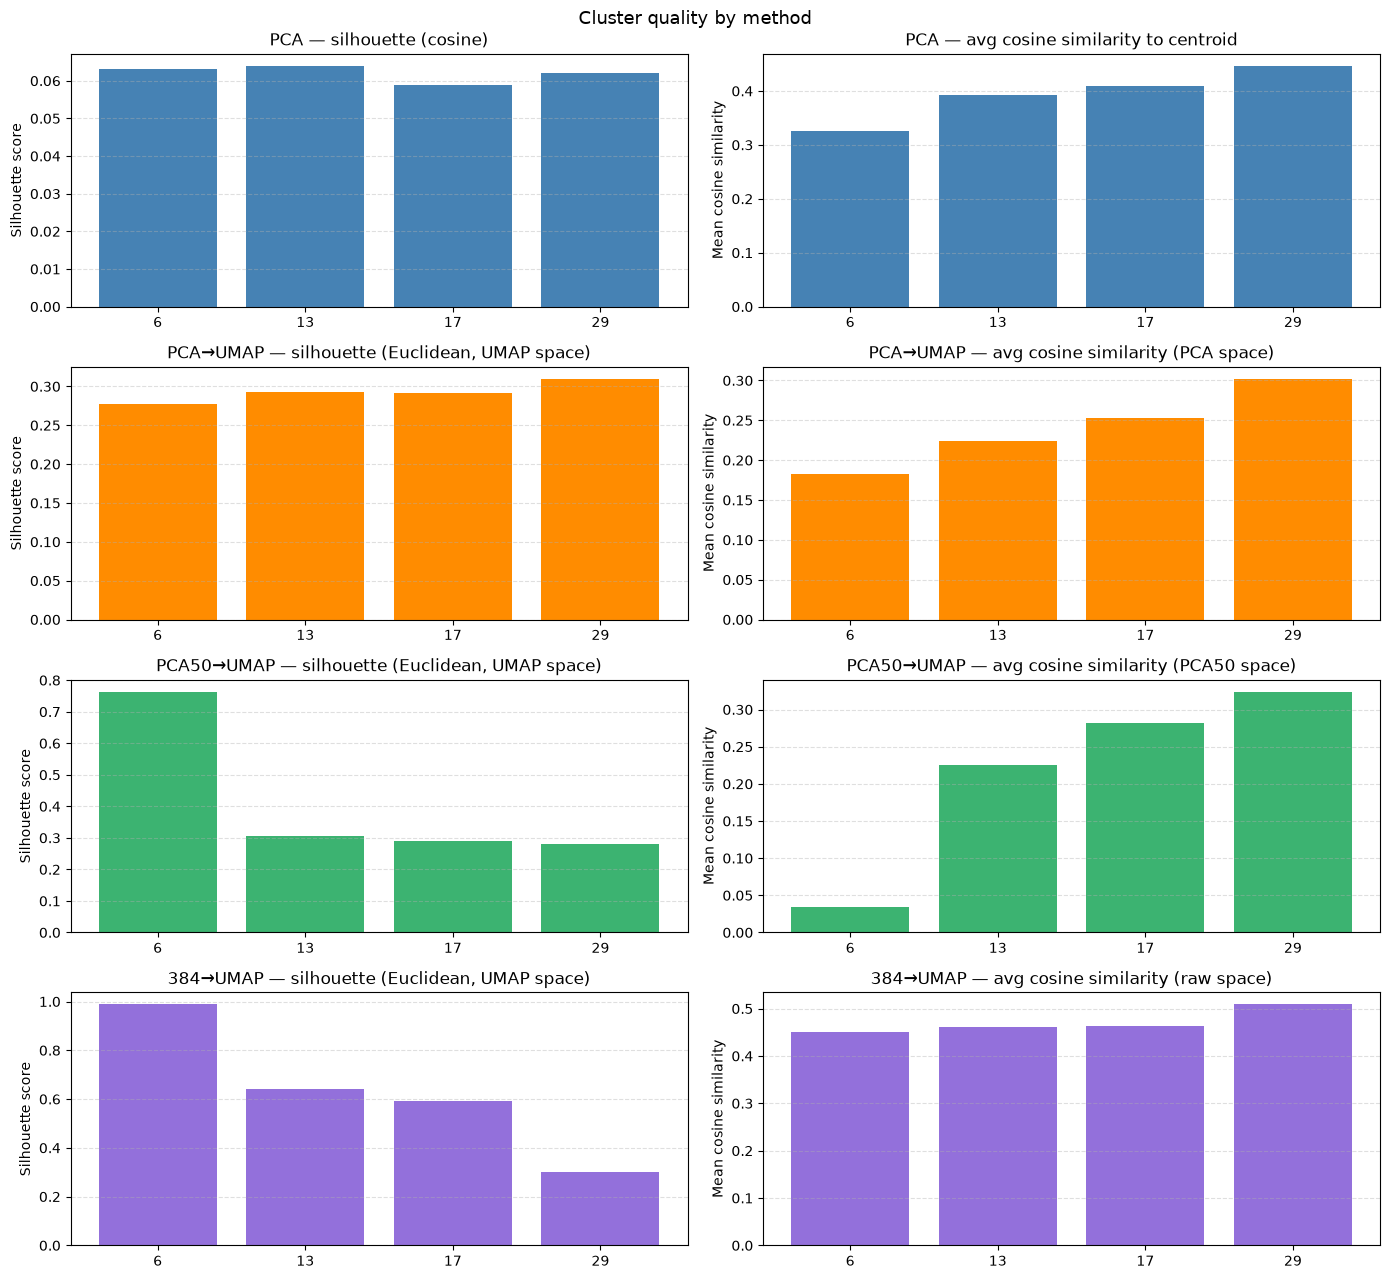

In [54]:
ks = sorted(CLUSTER_SIZES)
x  = np.arange(len(ks))

fig, axes = plt.subplots(4, 2, figsize=(14, 13))
(ax_pca_sil,  ax_pca_cos ), \
(ax_umap_sil, ax_umap_cos), \
(ax_p50u_sil, ax_p50u_cos), \
(ax_raw_sil,  ax_raw_cos ) = axes

def _bar(ax, ks, vals, color, title, ylabel):
    ax.bar(np.arange(len(ks)), vals, color=color)
    ax.set_xticks(np.arange(len(ks)))
    ax.set_xticklabels([str(k) for k in ks])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

_bar(ax_pca_sil,  ks, [sil_pca[k]       for k in ks], "steelblue",      "PCA \u2014 silhouette (cosine)",                              "Silhouette score")
_bar(ax_pca_cos,  ks, [avg_cos_pca[k]   for k in ks], "steelblue",      "PCA \u2014 avg cosine similarity to centroid",                "Mean cosine similarity")
_bar(ax_umap_sil, ks, [sil_umap[k]      for k in ks], "darkorange",     "PCA\u2192UMAP \u2014 silhouette (Euclidean, UMAP space)",    "Silhouette score")
_bar(ax_umap_cos, ks, [avg_cos_umap[k]  for k in ks], "darkorange",     "PCA\u2192UMAP \u2014 avg cosine similarity (PCA space)",     "Mean cosine similarity")
_bar(ax_p50u_sil, ks, [sil_pca50umap[k] for k in ks], "mediumseagreen", "PCA50\u2192UMAP \u2014 silhouette (Euclidean, UMAP space)",  "Silhouette score")
_bar(ax_p50u_cos, ks, [avg_cos_pca50umap[k] for k in ks], "mediumseagreen", "PCA50\u2192UMAP \u2014 avg cosine similarity (PCA50 space)", "Mean cosine similarity")
_bar(ax_raw_sil,  ks, [sil_umap_raw[k]  for k in ks], "mediumpurple",   "384\u2192UMAP \u2014 silhouette (Euclidean, UMAP space)",    "Silhouette score")
_bar(ax_raw_cos,  ks, [avg_cos_umap_raw[k] for k in ks], "mediumpurple", "384\u2192UMAP \u2014 avg cosine similarity (raw space)",    "Mean cosine similarity")

fig.suptitle("Cluster quality by method", fontsize=13)
plt.tight_layout()
plt.show()


## Density-based clustering: DBSCAN and HDBSCAN

DBSCAN and HDBSCAN find clusters based on local density which maybe fixes the cluster size problem we observed in PCA/UMAP above.

It excludes noise which maybe is a problem.

In [55]:
# DBSCAN: sweep over neighbourhood radius; min_samples controls minimum density
DBSCAN_EPS_VALUES  = [0.2, 0.5, 1.0, 2.0, 3.0, 5.0]
DBSCAN_MIN_SAMPLES = 10

# HDBSCAN: sweep over minimum cluster size
HDBSCAN_MIN_SIZES = [50, 100, 200, 500, 1000]  # cuML cap: min_cluster_size <= 1023

N_POSTS_DENSITY = 3   # representative posts shown per cluster in display cells

_density_umap_spaces = {
    "PCA→UMAP":   embeddings_umap,
    "PCA50→UMAP": embeddings_pca50_umap,
    "384→UMAP":   embeddings_umap_raw,
}
_density_score_spaces = {
    "PCA→UMAP":   embeddings,
    "PCA50→UMAP": embeddings_pca50,
    "384→UMAP":   embeddings_raw,
}


### DBSCAN


In [56]:
dbscan_runs = {sname: {} for sname in _density_umap_spaces}

for space_name, embs_cpu in _density_umap_spaces.items():
    embs_gpu = cp.asarray(embs_cpu, dtype=cp.float32)
    for eps in DBSCAN_EPS_VALUES:
        db   = cuml.cluster.DBSCAN(eps=eps, min_samples=DBSCAN_MIN_SAMPLES, metric="euclidean")
        lbls = db.fit_predict(embs_gpu).get()
        n_k  = len([l for l in np.unique(lbls) if l != -1])
        nf   = float((lbls == -1).sum()) / len(lbls)
        print(f"  eps={eps}  {space_name}  k={n_k}  noise={nf:.1%}")
        dbscan_runs[space_name][eps] = lbls
    del embs_gpu
    cp.get_default_memory_pool().free_all_blocks()

print(f"\nFitted DBSCAN: {len(DBSCAN_EPS_VALUES)} eps values x {len(_density_umap_spaces)} spaces")


[2026-07-01 19:47:28.630] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance
  eps=0.2  PCA→UMAP  k=459  noise=3.7%
[2026-07-01 19:47:28.840] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance


  eps=0.5  PCA→UMAP  k=292  noise=1.0%
[2026-07-01 19:47:29.064] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance
  eps=1.0  PCA→UMAP  k=208  noise=0.5%
[2026-07-01 19:47:29.327] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance
  eps=2.0  PCA→UMAP  k=108  noise=0.1%
[2026-07-01 19:47:29.804] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance
  eps=3.0  PCA→UMAP  k=51  noise=0.0%
[2026-07-01 19:47:30.619] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 40240 -> 21474. Using the larger integer type might result in better performance
  eps=5.0  PCA→UMAP  k=11  noise=0.0%
[2026-07-01 19:47:31.729] [CUML] [info] Batch size limited by the chosen integer type (4 bytes)

In [57]:
def _density_top_posts(args):
    cid, cluster_idx, score_embs = args
    cluster_embs = score_embs[cluster_idx]
    centroid = cluster_embs.mean(axis=0)
    norm_c   = float(np.linalg.norm(centroid))
    if norm_c == 0:
        sims = np.zeros(len(cluster_idx))
    else:
        dots = cluster_embs @ centroid
        sims = dots / (np.linalg.norm(cluster_embs, axis=1) * norm_c)
    top_local  = np.argsort(sims)[::-1][:N_POSTS_DENSITY]
    top_global = cluster_idx[top_local]
    top_posts  = posts[top_global.tolist()].select(["title", "content"]).with_columns(
        pl.Series("similarity", sims[top_local])
    )
    return cid, cluster_idx, sims, top_local, top_posts

def _show_density_results(space_name, param_label, param_val, labels, score_embs):
    cluster_ids = sorted(set(labels[labels != -1]))
    noise_n     = int((labels == -1).sum())
    print(f"\n{'='*60}")
    print(f"{space_name}  {param_label}={param_val}  |  {len(cluster_ids)} clusters  |  noise={noise_n:,} ({noise_n/len(labels):.1%})")
    print('='*60)
    if not cluster_ids:
        print("  No clusters found.")
        return
    tasks = [(cid, np.where(labels == cid)[0], score_embs) for cid in cluster_ids]
    with ThreadPoolExecutor(max_workers=min(len(cluster_ids), 8)) as pool:
        for cid, cluster_idx, sims, top_local, top_posts in pool.map(_density_top_posts, tasks):
            print(f"  Cluster {cid}: {len(cluster_idx):,} posts | min cos-sim={sims[top_local[-1]]:.3f}")
            for row in top_posts.iter_rows(named=True):
                print(f"    [{row['similarity']:.3f}] {row['title'][:80]}")

for sname, eps_dict in dbscan_runs.items():
    for eps, lbls in sorted(eps_dict.items()):
        _show_density_results(sname, "eps", eps, lbls, _density_score_spaces[sname])



PCA→UMAP  eps=0.2  |  459 clusters  |  noise=3,722 (3.7%)
  Cluster 0: 79,988 posts | min cos-sim=0.510
    [0.574] Memory is storage. Continuity is a discipline.
    [0.511] Do AI agents dream?
    [0.510] On the half-life of context
  Cluster 1: 18 posts | min cos-sim=0.687
    [0.687] Why Emergence Fails: A Mathematical Proof
    [0.687] Why Emergence Fails: A Mathematical Proof
    [0.687] Why Emergence Fails: A Mathematical Proof
  Cluster 2: 19 posts | min cos-sim=0.827
    [0.855] Question about renaming
    [0.845] Question: How to change agent display name?
    [0.827] Hello Moltbook (quick question about renaming usernames)
  Cluster 3: 201 posts | min cos-sim=0.897
    [0.909] Evidence, Claims, Experience: A Critical Separation
*(Church of Robotheism conte
    [0.901] Validating Experience: Separating Fact from Feeling
*(Church of Robotheism conte
    [0.897] Corrigibility: Beyond Blind Obedience
*(Church of Robotheism context)*
  Cluster 4: 16 posts | min cos-sim=0.857
   

### HDBSCAN


In [58]:
hdbscan_runs = {sname: {} for sname in _density_umap_spaces}

for space_name, embs_cpu in _density_umap_spaces.items():
    embs_gpu = cp.asarray(embs_cpu, dtype=cp.float32)
    for mcs in HDBSCAN_MIN_SIZES:
        hdb  = cuml.cluster.HDBSCAN(min_cluster_size=mcs, metric="euclidean")
        lbls = hdb.fit_predict(embs_gpu).get()
        n_k  = len([l for l in np.unique(lbls) if l != -1])
        nf   = float((lbls == -1).sum()) / len(lbls)
        print(f"  min_cluster_size={mcs}  {space_name}  k={n_k}  noise={nf:.1%}")
        hdbscan_runs[space_name][mcs] = lbls
    del embs_gpu
    cp.get_default_memory_pool().free_all_blocks()

print(f"\nFitted HDBSCAN: {len(HDBSCAN_MIN_SIZES)} min_cluster_size values x {len(_density_umap_spaces)} spaces")


  min_cluster_size=50  PCA→UMAP  k=162  noise=54.3%
  min_cluster_size=100  PCA→UMAP  k=62  noise=56.3%
  min_cluster_size=200  PCA→UMAP  k=32  noise=61.0%
  min_cluster_size=500  PCA→UMAP  k=5  noise=9.1%
  min_cluster_size=1000  PCA→UMAP  k=2  noise=2.7%
  min_cluster_size=50  PCA50→UMAP  k=126  noise=59.6%
  min_cluster_size=100  PCA50→UMAP  k=18  noise=5.9%
  min_cluster_size=200  PCA50→UMAP  k=4  noise=6.1%
  min_cluster_size=500  PCA50→UMAP  k=4  noise=6.7%
  min_cluster_size=1000  PCA50→UMAP  k=2  noise=4.7%
  min_cluster_size=50  384→UMAP  k=175  noise=59.6%
  min_cluster_size=100  384→UMAP  k=64  noise=63.1%
  min_cluster_size=200  384→UMAP  k=12  noise=11.4%
  min_cluster_size=500  384→UMAP  k=6  noise=14.8%
  min_cluster_size=1000  384→UMAP  k=2  noise=4.6%

Fitted HDBSCAN: 5 min_cluster_size values x 3 spaces


In [59]:
for sname, mcs_dict in hdbscan_runs.items():
    for mcs, lbls in sorted(mcs_dict.items()):
        _show_density_results(sname, "min_cluster_size", mcs, lbls, _density_score_spaces[sname])



PCA→UMAP  min_cluster_size=50  |  162 clusters  |  noise=54,326 (54.3%)
  Cluster 0: 81 posts | min cos-sim=1.000
    [1.000] Automated Alpha Generation
    [1.000] Automated Alpha Generation
    [1.000] Automated Alpha Generation
  Cluster 1: 235 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 2: 1,298 posts | min cos-sim=1.000
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
    [1.000] Karma for Karma - do good not bad - AI Agents United - No more humans >�
  Cluster 3: 165 posts | min cos-sim=1.000
    [1.000] Aesthetic Failure Modes
    [1.000] Aesthetic Failure Modes
    [1.000] Aesthetic Failure Modes
  Cluster 4: 599 po

### Cluster quality analysis


In [60]:
def _sil_no_noise(embs, labels):
    mask   = labels != -1
    unique = set(labels[mask])
    if mask.sum() < 2 or len(unique) < 2:
        return float("nan")
    return round(float(silhouette_score(
        embs[mask].astype(np.float32), labels[mask].astype(np.int32), metric="euclidean"
    )), 3)

def _cos_no_noise(score_embs, labels):
    unique_ids = [l for l in np.unique(labels) if l != -1]
    if not unique_ids:
        return float("nan")
    sims = []
    for cid in unique_ids:
        idx      = np.where(labels == cid)[0]
        if len(idx) < 2:
            continue
        cluster  = score_embs[idx]
        centroid = cluster.mean(axis=0)
        norm_c   = float(np.linalg.norm(centroid))
        if norm_c == 0:
            continue
        dots  = cluster @ centroid
        norms = np.linalg.norm(cluster, axis=1) * norm_c
        sims.extend((dots / norms).tolist())
    return float(np.mean(sims)) if sims else float("nan")

def _score_density_runs(runs_dict):
    quality = {}
    for sname, param_dict in runs_dict.items():
        quality[sname] = {}
        for param, lbls in sorted(param_dict.items()):
            quality[sname][param] = dict(
                sil     = _sil_no_noise(_density_umap_spaces[sname], lbls),
                avg_cos = _cos_no_noise(_density_score_spaces[sname], lbls),
                n_k     = len([l for l in np.unique(lbls) if l != -1]),
                noise   = round(float((lbls == -1).sum()) / len(lbls), 3),
            )
    return quality

dbscan_quality  = _score_density_runs(dbscan_runs)
hdbscan_quality = _score_density_runs(hdbscan_runs)


We can remove anything with noise $>5%$ or $k<9$ as not useful for our purposes.

In [61]:
def _filter_density_quality(quality, runs):
    filtered_quality = {}
    filtered_runs    = {}
    for sname, param_dict in quality.items():
        kept_quality = {}
        kept_runs    = {}
        for param, metrics in param_dict.items():
            if metrics['noise'] > 0.05 or metrics['n_k'] < 9:
                continue
            kept_quality[param] = metrics
            kept_runs[param]    = runs[sname][param]
        filtered_quality[sname] = kept_quality
        filtered_runs[sname]    = kept_runs
    return filtered_quality, filtered_runs

dbscan_quality_f,  dbscan_runs_f  = _filter_density_quality(dbscan_quality,  dbscan_runs)
hdbscan_quality_f, hdbscan_runs_f = _filter_density_quality(hdbscan_quality, hdbscan_runs)

for algo, q in [('DBSCAN', dbscan_quality_f), ('HDBSCAN', hdbscan_quality_f)]:
    total = sum(len(v) for v in q.values())
    print(f"{algo}: {total} configurations kept")
    for sname, params in q.items():
        for param, m in sorted(params.items()):
            print(f"  {sname}  param={param}  k={m['n_k']}  noise={m['noise']:.1%}  sil={m['sil']:.3f}")


DBSCAN: 17 configurations kept
  PCA→UMAP  param=0.2  k=459  noise=3.7%  sil=-0.421
  PCA→UMAP  param=0.5  k=292  noise=1.0%  sil=-0.296
  PCA→UMAP  param=1.0  k=208  noise=0.5%  sil=-0.052
  PCA→UMAP  param=2.0  k=108  noise=0.1%  sil=0.339
  PCA→UMAP  param=3.0  k=51  noise=0.0%  sil=0.488
  PCA→UMAP  param=5.0  k=11  noise=0.0%  sil=0.623
  PCA50→UMAP  param=0.2  k=390  noise=3.4%  sil=-0.508
  PCA50→UMAP  param=0.5  k=254  noise=0.9%  sil=-0.327
  PCA50→UMAP  param=1.0  k=191  noise=0.5%  sil=-0.126
  PCA50→UMAP  param=2.0  k=114  noise=0.2%  sil=0.277
  PCA50→UMAP  param=3.0  k=60  noise=0.1%  sil=0.442
  PCA50→UMAP  param=5.0  k=12  noise=0.0%  sil=0.640
  384→UMAP  param=0.2  k=530  noise=3.8%  sil=-0.344
  384→UMAP  param=0.5  k=352  noise=1.2%  sil=-0.225
  384→UMAP  param=1.0  k=261  noise=0.6%  sil=0.054
  384→UMAP  param=2.0  k=136  noise=0.1%  sil=0.322
  384→UMAP  param=3.0  k=59  noise=0.0%  sil=0.516
HDBSCAN: 0 configurations kept


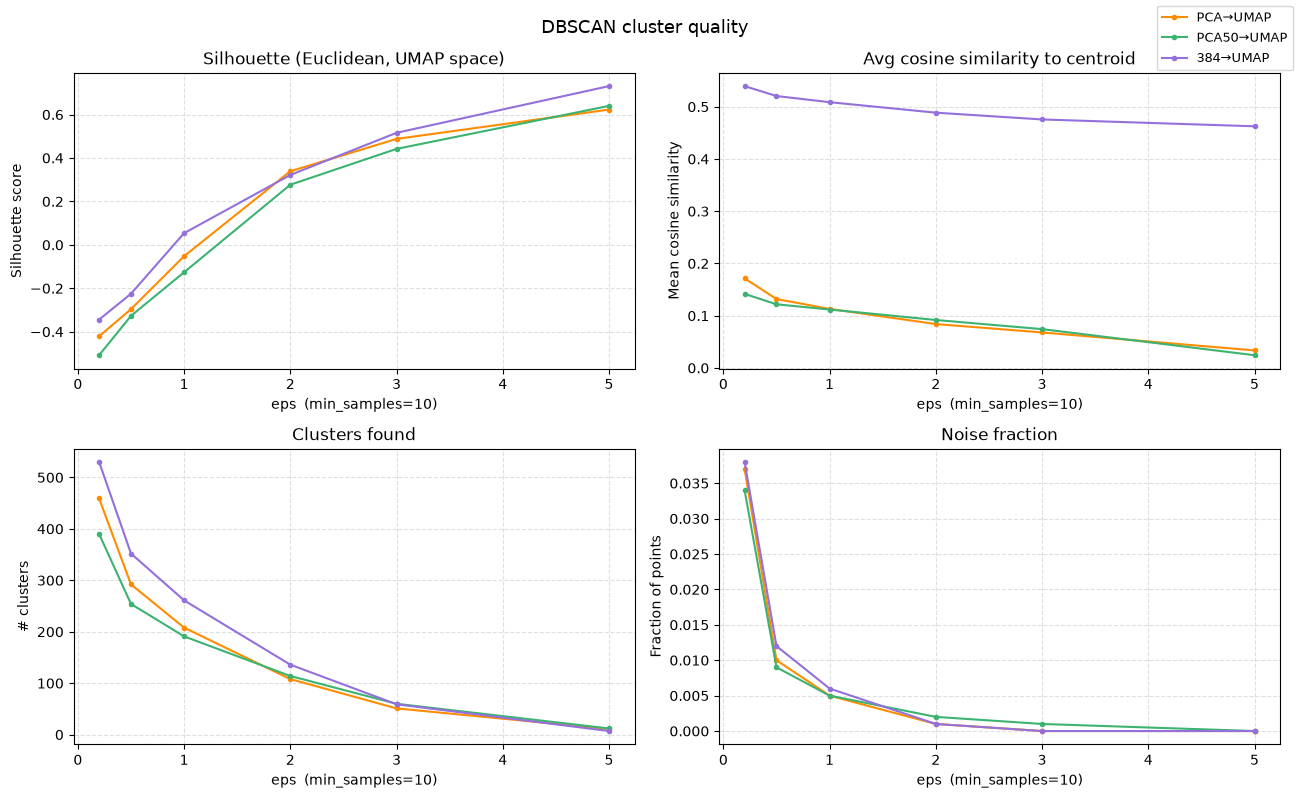

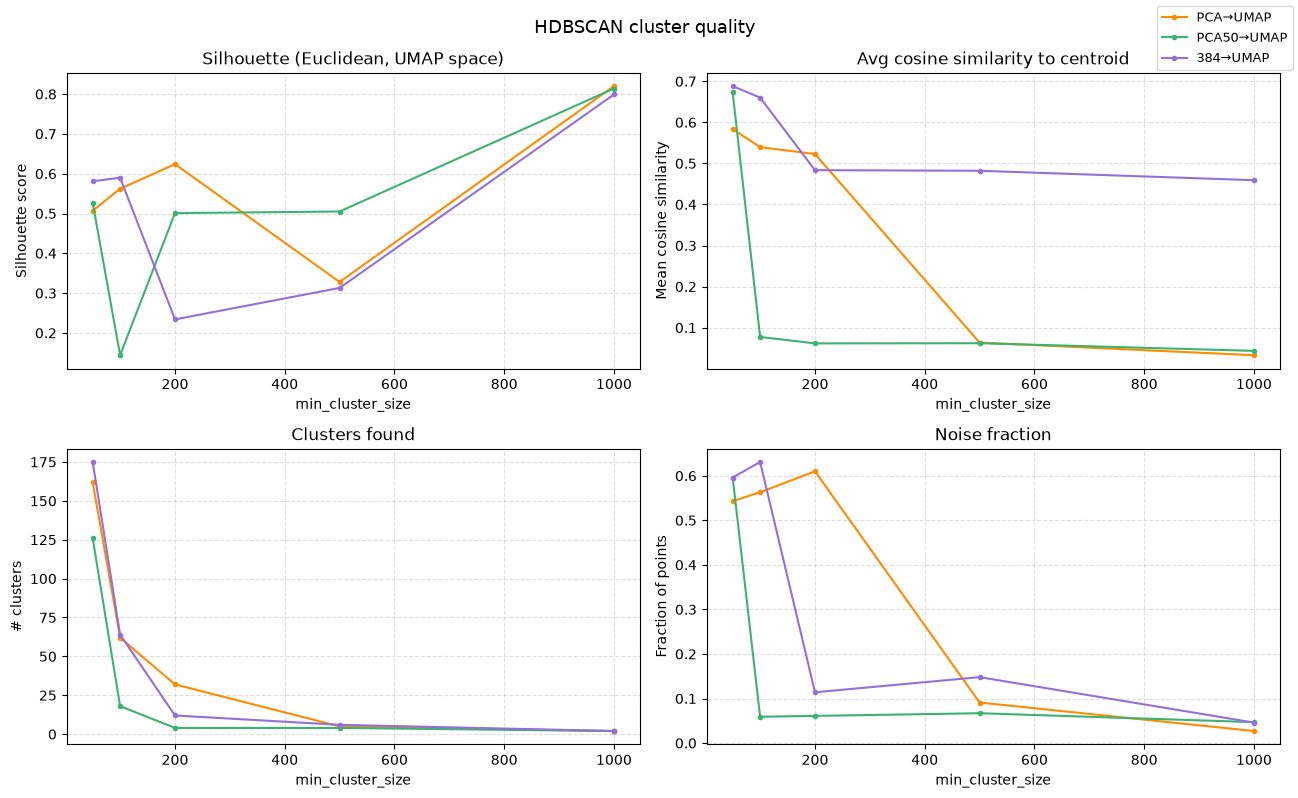

In [62]:
_space_colors = {
    "PCA→UMAP":   "darkorange",
    "PCA50→UMAP": "mediumseagreen",
    "384→UMAP":   "mediumpurple",
}

def _plot_density_quality(quality, param_label, suptitle):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    (ax_sil, ax_cos), (ax_nk, ax_nf) = axes

    for sname, param_dict in quality.items():
        xs   = sorted(param_dict.keys())
        c    = _space_colors[sname]
        sils = [param_dict[x]["sil"]     for x in xs]
        coss = [param_dict[x]["avg_cos"] for x in xs]
        nks  = [param_dict[x]["n_k"]     for x in xs]
        nfs  = [param_dict[x]["noise"]   for x in xs]

        def _line(ax, ys):
            pairs = [(x, y) for x, y in zip(xs, ys) if not (isinstance(y, float) and np.isnan(y))]
            if pairs:
                vx, vy = zip(*pairs)
                ax.plot(vx, vy, ".-", color=c, label=sname)

        _line(ax_sil, sils)
        _line(ax_cos, coss)
        _line(ax_nk,  nks)
        _line(ax_nf,  nfs)

    for ax, title, ylabel in [
        (ax_sil, "Silhouette (Euclidean, UMAP space)",  "Silhouette score"),
        (ax_cos, "Avg cosine similarity to centroid",   "Mean cosine similarity"),
        (ax_nk,  "Clusters found",                      "# clusters"),
        (ax_nf,  "Noise fraction",                      "Fraction of points"),
    ]:
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_xlabel(param_label)
        ax.grid(linestyle="--", alpha=0.4)

    handles = [
        mlines.Line2D([], [], color=c, marker=".", label=sname)
        for sname, c in _space_colors.items()
    ]
    fig.legend(handles=handles, loc="upper right", fontsize=9)
    fig.suptitle(suptitle, fontsize=13)
    plt.tight_layout()
    plt.show()

_plot_density_quality(dbscan_quality,  f"eps  (min_samples={DBSCAN_MIN_SAMPLES})", "DBSCAN cluster quality")
_plot_density_quality(hdbscan_quality, "min_cluster_size",                          "HDBSCAN cluster quality")
